<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW3_PT2_322512690_212393532_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Assignment 3 - Part 2
### Latent Space Visualization

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532

# Imports

In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F
import random

# Preprocessing

In [2]:
# create a transofrm to apply to each datapoint
transform = transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]


Extracting /root/datasets/MNIST/raw/train-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]


Extracting /root/datasets/MNIST/raw/train-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.85MB/s]


Extracting /root/datasets/MNIST/raw/t10k-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


Extracting /root/datasets/MNIST/raw/t10k-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw



# Encoder Class

In [3]:
class Encoder(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1=nn.Linear(input_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,latent_dim)


    def forward(self, x):

      x=x.view(x.size(0),-1)  #flattern the input
      x=F.relu(self.fc1(x))
      x=self.fc2(x)
      return x


# Decoder Class

In [4]:
class Decoder(nn.Module):

    def __init__(self, output_dim, hidden_dim, latent_dim):
        super(Decoder, self).__init__()
        self.fc1=nn.Linear(latent_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        self.fc3=nn.Linear(hidden_dim,output_dim)


    def forward(self, x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=torch.sigmoid(self.fc3(x))
        x=x.view(x.size(0),1,28,28)  # reshape to image format
        return x

# Variational Auto Encoder Class

In [5]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200, device=device):
        super(VAE, self).__init__()

        self.device= device
        self.encoder=Encoder(input_dim,hidden_dim,latent_dim *2)
        self.decoder=Decoder(input_dim,hidden_dim,latent_dim)


    def reparameterize(self,mu,log_var):

        std=torch.exp(0.5*log_var)
        epslion=torch.randn_like(std)
        z=mu+epslion*std
        return z

    def encode(self,x):

      x=self.encoder(x)
      mu,logvar=torch.chunk(x,2,dim=1)
      return mu,logvar


    def forward(self, x):
        # write your code here

        x=x.view(x.size(0),-1)
        mu,logvar=self.encode(x)
        z=self.reparameterize(mu,logvar)
        recon_x=self.decoder(z)
        return recon_x,mu,logvar

In [6]:
model = VAE().to(device)
lr=0.001
optimizer = Adam(model.parameters(), lr)

# Loss Function Class


i add the 1e-10 to avoid log(0)

In [7]:
def loss_function(x, x_hat, mean, log_var):
    # write your code heres

    x_hat=x_hat.view(x.size(0),-1)

    bce_loss=-torch.sum(x*torch.log(x_hat+ 1e-10)+(1-x)*torch.log(1-x_hat+ 1e-10),dim=1)
    loss_reprod=torch.mean(bce_loss)

    kld=-0.5*torch.sum(1+log_var-mean.pow(2)-log_var.exp(),dim=1)
    KLD=torch.mean(kld)


    return loss_reprod + KLD

# Training Loop

In [8]:
def train(model, optimizer, epochs, device, x_dim=784): # Modify, add the evaluation step after each 10 epochs
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, x_dim).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))

        # After 10 epochs , generate and plot a digit
        if (epoch+1) % 10 ==0:

          with torch.no_grad():

            z=torch.randn(1,model.decoder.fc1.in_features,device=device)

            generated_digit=model.decoder(z).squeeze().cpu().detach().numpy()


            # plot the generated digit
            plt.imshow(generated_digit,cmap='gray')
            plt.axis('off')
            plt.title(f"Generated Image at Epoch {epoch+1}")
            plt.show()


    return overall_loss

	Epoch 1 	Average Loss:  1.8176147988244569
	Epoch 2 	Average Loss:  1.4121575769796992
	Epoch 3 	Average Loss:  1.2413213904990577
	Epoch 4 	Average Loss:  1.1723448857480974
	Epoch 5 	Average Loss:  1.1308983642629074
	Epoch 6 	Average Loss:  1.1052866967253772
	Epoch 7 	Average Loss:  1.0867645198713758
	Epoch 8 	Average Loss:  1.0753508380259418
	Epoch 9 	Average Loss:  1.0674569577326958
	Epoch 10 	Average Loss:  1.0606181802892924


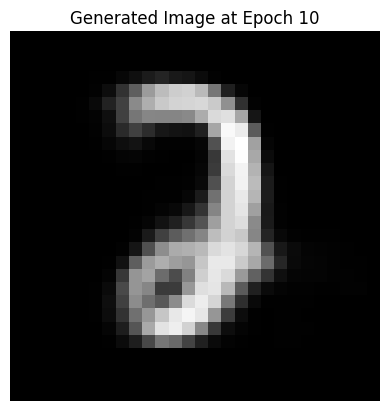

	Epoch 11 	Average Loss:  1.0547373756064795
	Epoch 12 	Average Loss:  1.0502606761594846
	Epoch 13 	Average Loss:  1.0456209191018233
	Epoch 14 	Average Loss:  1.0419233992740586
	Epoch 15 	Average Loss:  1.0381311153609287
	Epoch 16 	Average Loss:  1.0343687617281243
	Epoch 17 	Average Loss:  1.0304365179096917
	Epoch 18 	Average Loss:  1.0277948264247787
	Epoch 19 	Average Loss:  1.0245955072062243
	Epoch 20 	Average Loss:  1.0223822803529157


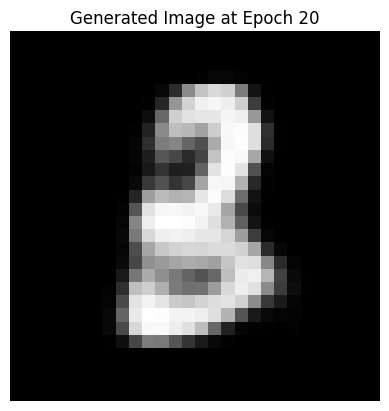

	Epoch 21 	Average Loss:  1.0204812157173984
	Epoch 22 	Average Loss:  1.0185661503150187
	Epoch 23 	Average Loss:  1.015954628945989
	Epoch 24 	Average Loss:  1.0146755864265964
	Epoch 25 	Average Loss:  1.012932597114168
	Epoch 26 	Average Loss:  1.011848733102738
	Epoch 27 	Average Loss:  1.0104313397288123
	Epoch 28 	Average Loss:  1.0086558177355733
	Epoch 29 	Average Loss:  1.0086608426917176
	Epoch 30 	Average Loss:  1.0071289663681005


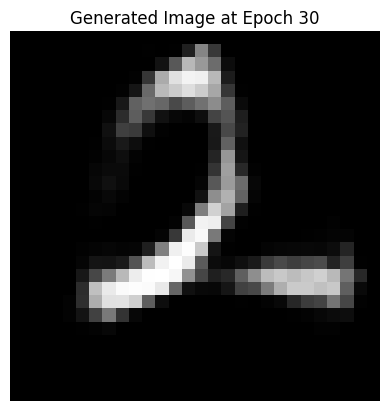

	Epoch 31 	Average Loss:  1.0062438794169482
	Epoch 32 	Average Loss:  1.00523742370096
	Epoch 33 	Average Loss:  1.004279391586482
	Epoch 34 	Average Loss:  1.0042091015543484
	Epoch 35 	Average Loss:  1.0029429662128124
	Epoch 36 	Average Loss:  1.0019851150894803
	Epoch 37 	Average Loss:  1.0019029128850003
	Epoch 38 	Average Loss:  1.0011524225913224
	Epoch 39 	Average Loss:  1.0004589963476727
	Epoch 40 	Average Loss:  0.9995092262688383


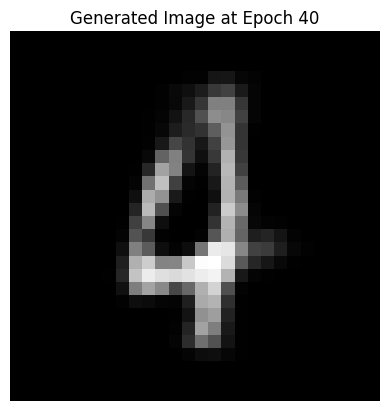

	Epoch 41 	Average Loss:  0.999818199807296
	Epoch 42 	Average Loss:  0.9988429009337259
	Epoch 43 	Average Loss:  0.9980422945611664
	Epoch 44 	Average Loss:  0.9974332268767444
	Epoch 45 	Average Loss:  0.9965717446863751
	Epoch 46 	Average Loss:  0.9965478482509097
	Epoch 47 	Average Loss:  0.9962121657178875
	Epoch 48 	Average Loss:  0.9954468168280957
	Epoch 49 	Average Loss:  0.9952900806611686
	Epoch 50 	Average Loss:  0.9949096622371514


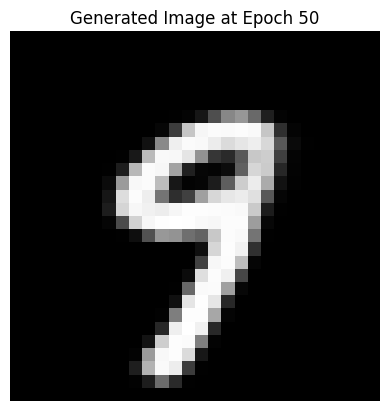

59595.08876800537

In [9]:
train(model, optimizer, epochs=50, device=device)

# Generate and plot digit

In [10]:
def generate_digit(mean, var):


    # write your code here


    std=var**0.5

    epslion=torch.randn(1,200, device=device)

    z=mean+epslion*std

    generated_digit=model.decoder(z)




    def plot_digit(): # plot the generated digit
        # write your code here

        img=generated_digit.squeeze().cpu().detach().numpy()

        plt.imshow(img,cmap='gray')
        plt.axis('off')
        plt.show()


    plot_digit()

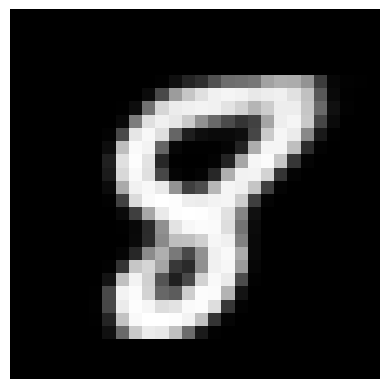

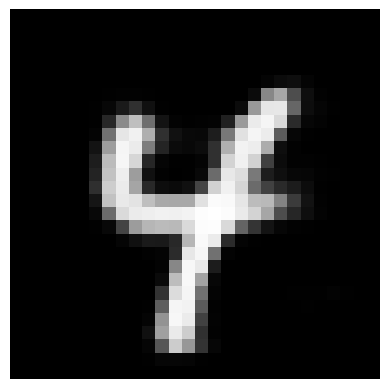

(None, None)

In [12]:
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

# Latent Space Grid Visualization

In [24]:
def plot_latent_space(model, scale, digit_size=28, figsize=15):
    # write your code here

    n=10  # number of images per row and col

    fig,ax=plt.subplots(n,n,figsize=(figsize,figsize))

    grid_x=np.linspace(-scale,scale,n)
    grid_y=np.linspace(-scale,scale,n)

    for i , yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):

           z_sample=torch.tensor([xi,yi] ,dtype=torch.float32, device=device).unsqueeze(0)

           if model.decoder.fc1.in_features >2 :

              latent_dim=model.decoder.fc1.in_features
              z_padded=torch.zeros(1,latent_dim,device=device)
              z_padded[:,:2]=z_sample
              z_sample=z_padded


           generated_digit=model.decoder(z_sample)

           digit=generated_digit.squeeze().cpu().detach().numpy()

           ax[i,j].imshow(digit,cmap='gray')
           ax[i,j].axis('off')

    plt.show()


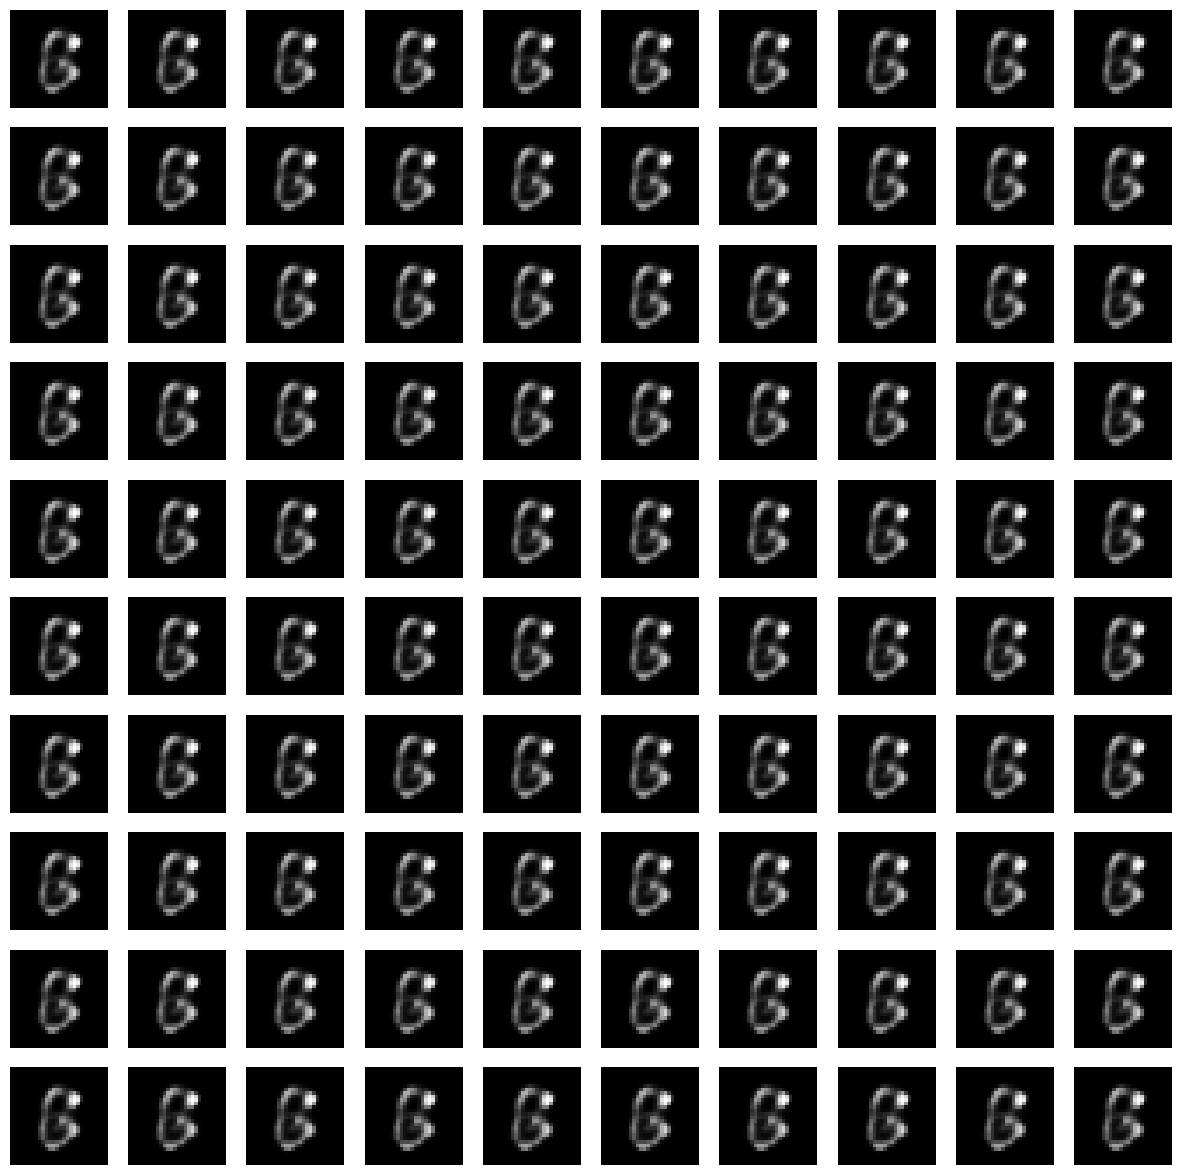

In [25]:
plot_latent_space(model, scale=1.0)

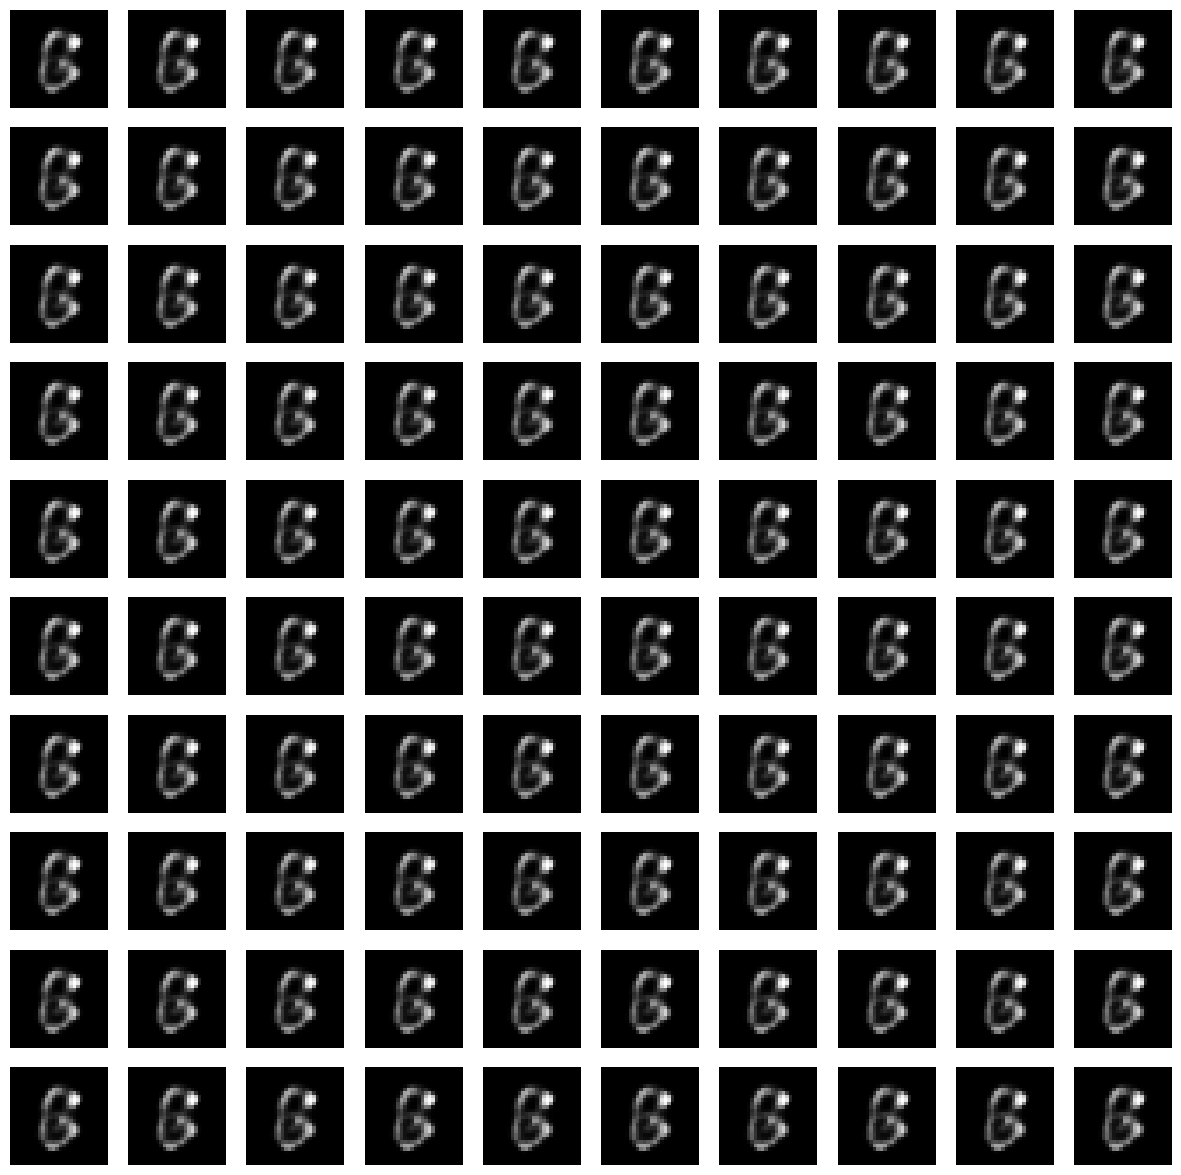

In [21]:
plot_latent_space(model, scale=5.0)

# Linear Interpolation

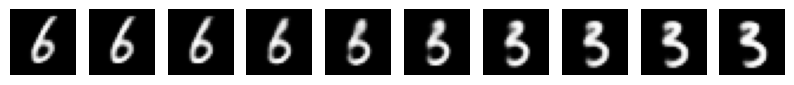

In [18]:
# write your code here
def linear_interpolation(model,dataset,num_steps=10):

  model.eval()

  # select two random digits
  indx1,indx2=random.sample(range(len(dataset)),2)

  img1,label1=dataset[indx1]
  img2,label2=dataset[indx2]



  img1=img1.view(1,-1).to(device)
  img2=img2.view(1,-1).to(device)


  with torch.no_grad():

    mu1,logvar1=model.encode(img1)
    mu2,logvar2=model.encode(img2)


    z1=mu1
    z2=mu2


  t_values=torch.linspace(0,1,num_steps,device=device)

  fig,axes=plt.subplots(1,num_steps,figsize=(num_steps,2))


  for i,t in enumerate(t_values):

    z_interpolated=(1-t)*z1 + t*z2

    with torch.no_grad():

      x_decoded=model.decoder(z_interpolated)

    digit_img=x_decoded.squeeze().cpu().detach().numpy()

    axes[i].imshow(digit_img,cmap='gray')
    axes[i].axis('off')


  plt.show()





linear_interpolation(model,test_dataset,num_steps=10)

